# Approximation Node Optimizer (ANO) — Core Geometric Engine

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import qr
import ipywidgets as widgets
from IPython.display import display, clear_output
from mpl_toolkits.mplot3d import Axes3D

# Global research log to store experiment metrics for the thesis
stats_journal = []

# =====================================================================
# 1. GEOMETRIC OBJECTS (DOMAINS) — MULTIDIMENSIONAL TOPOLOGIES
# =====================================================================

class Domain:
    """Abstract base class establishing the interface for all geometric domains."""
    def __init__(self, name, dim=2):
        self.name = name
        self.dim = dim

    def contains(self, *args):
        """Check if given coordinates lie within the domain boundaries."""
        raise NotImplementedError

    def get_boundary(self):
        """Return coordinates to plot the 2D boundary layout."""
        return []

class Square(Domain):
    """Standard 2D Square domain bounded within [-1, 1] x [-1, 1]."""
    def __init__(self):
        super().__init__("Square", dim=2)

    def contains(self, x, y):
        return (np.abs(x) <= 1) & (np.abs(y) <= 1)

    def get_boundary(self):
        return [([-1, 1, 1, -1, -1], [-1, -1, 1, 1, -1])]

class Disk(Domain):
    """Standard 2D Unit Disk domain."""
    def __init__(self):
        super().__init__("Disk", dim=2)

    def contains(self, x, y):
        return x**2 + y**2 <= 1 + 1e-9

    def get_boundary(self):
        t = np.linspace(0, 2 * np.pi, 200)
        return [(np.cos(t), np.sin(t))]

class Sector(Domain):
    """Non-convex 3/4 Sector Disk (Unit Disk with the 3rd quadrant removed).
    Explicitly constructed via three separate, visible path segments.
    """
    def __init__(self):
        super().__init__("Sector (3/4 Disk)", dim=2)

    def contains(self, x, y):
        in_disk = x**2 + y**2 <= 1 + 1e-9
        # Third quadrant is strictly x < 0 and y < 0
        in_third_quadrant = (x < 0) & (y < 0)
        return in_disk & (~in_third_quadrant)

    def get_boundary(self):
        # 1. Дуга: от 0 до 1.5*pi (это 1-я, 2-я и 4-я четверти, если идти против часовой)
        # Но чтобы выкинуть 3-ю четверть, мы стартуем от -0.5*pi (точка 0, -1) и идем до pi (точка -1, 0)
        t = np.linspace(-0.5 * np.pi, np.pi, 200)
        arc_x = np.cos(t)
        arc_y = np.sin(t)

        # 2. Отрезок от конца дуга (-1, 0) до центра (0, 0)
        line1_x = np.linspace(-1, 0, 50)
        line1_y = np.zeros(50)

        # 3. Отрезок от центра (0, 0) до старта дуги (0, -1)
        line2_x = np.zeros(50)
        line2_y = np.linspace(0, -1, 50)

        # Просто собираем их друг за другом в один сплошной контур
        bx = np.concatenate([arc_x, line1_x, line2_x])
        by = np.concatenate([arc_y, line1_y, line2_y])

        return [(bx, by)]
class Triangle(Domain):
    """Standard 2D Right Triangle domain with vertices at (0,0), (1,0), and (0,1)."""
    def __init__(self):
        super().__init__("Triangle", dim=2)

    def contains(self, x, y):
        return (x >= 0) & (y >= 0) & (x + y <= 1)

    def get_boundary(self):
        return [([0, 1, 0, 0], [0, 0, 1, 0])]

class DoubleSquare(Domain):
    """Two distinct square domains connected via a narrow narrow bridge coordinate system."""
    def __init__(self):
        super().__init__("Double Square", dim=2)

    def contains(self, x, y):
        sq1 = (x >= -1.5) & (x <= -0.5) & (y >= -0.5) & (y <= 0.5)
        sq2 = (x >= 0.5) & (x <= 1.5) & (y >= -0.5) & (y <= 0.5)
        bridge = (x >= -0.5) & (x <= 0.5) & (np.abs(y) <= 0.1)
        return sq1 | sq2 | bridge

    def get_boundary(self):
        return [([-1.5, -0.5, -0.5, 0.5, 0.5, 1.5, 1.5, 0.5, 0.5, -0.5, -0.5, -1.5, -1.5],
                 [-0.5, -0.5, -0.1, -0.1, -0.5, -0.5, 0.5, 0.5, 0.1, 0.1, 0.5, 0.5, -0.5])]

class Annulus(Domain):
    """2D Annulus domain bounded by an inner radius (r_in) and outer radius (r_out)."""
    def __init__(self, r_in=0.4, r_out=1.0):
        super().__init__("Annulus", dim=2)
        self.r_in, self.r_out = r_in, r_out

    def contains(self, x, y):
        r2 = x**2 + y**2
        return (r2 >= self.r_in**2) & (r2 <= self.r_out**2)

    def get_boundary(self):
        t = np.linspace(0, 2 * np.pi, 200)
        return [(self.r_out * np.cos(t), self.r_out * np.sin(t)),
                (self.r_in * np.cos(t), self.r_in * np.sin(t))]

class Rhombus(Domain):
    """Standard 2D Rhombus (Diamond) domain layout."""
    def __init__(self):
        super().__init__("Rhombus", dim=2)

    def contains(self, x, y):
        return np.abs(x) + np.abs(y) <= 1

    def get_boundary(self):
        return [([1, 0, -1, 0, 1], [0, 1, 0, -1, 0])]

class EquilateralTriangle(Domain):
    """2D Equilateral Triangle centered with a fixed geometric height vector."""
    def __init__(self):
        super().__init__("Equi-Triangle", dim=2)

    def contains(self, x, y):
        h = np.sqrt(3) / 2
        cond1 = y >= 0
        cond2 = y <= -np.sqrt(3) * x + h
        cond3 = y <= np.sqrt(3) * x + h
        return cond1 & cond2 & cond3

    def get_boundary(self):
        h = np.sqrt(3) / 2
        return [([-0.5, 0.5, 0, -0.5], [0, 0, h, 0])]

class DisjointSquares(Domain):
    """Two completely separate, disconnected square spaces to analyze nodal partitioning."""
    def __init__(self):
        super().__init__("Disjoint Squares", dim=2)

    def contains(self, x, y):
        sq1 = (np.abs(x + 1) <= 0.4) & (np.abs(y) <= 0.4)
        sq2 = (np.abs(x - 1) <= 0.4) & (np.abs(y) <= 0.4)
        return sq1 | sq2

    def get_boundary(self):
        return [([-1.4, -0.6, -0.6, -1.4, -1.4], [-0.4, -0.4, 0.4, 0.4, -0.4]),
                ([0.6, 1.4, 1.4, 0.6, 0.6], [-0.4, -0.4, 0.4, 0.4, -0.4])]

class Interval1D(Domain):
    """Standard 1D canonical interval domain mapped to [-1, 1]."""
    def __init__(self):
        super().__init__("Interval [-1, 1]", dim=1)

    def contains(self, x):
        return np.abs(x) <= 1

    def get_boundary(self):
        return [([-1, 1], [0, 0])]

# =====================================================================
# 3D SPATIAL MANIFOLDS
# =====================================================================

class Sphere3D(Domain):
    """3D Solid Unit Sphere solid volume domain."""
    def __init__(self):
        super().__init__("Sphere3D", dim=3)

    def contains(self, x, y, z):
        return x**2 + y**2 + z**2 <= 1 + 1e-9

    def plot_surface(self, ax):
        """Generate wireframe mesh surface rendering for matplotlib 3D visualizers."""
        u, v = np.mgrid[0:2*np.pi:30j, 0:np.pi:15j]
        x = np.cos(u) * np.sin(v)
        y = np.sin(u) * np.sin(v)
        z = np.cos(v)
        ax.plot_wireframe(x, y, z, color="green", alpha=0.3, linewidth=0.5)

class Cylinder3D(Domain):
    """3D Solid Cylinder volume configuration with custom radius and height."""
    def __init__(self, r=1.0, h=2.0):
        super().__init__("Cylinder3D", dim=3)
        self.r, self.h = r, h

    def contains(self, x, y, z):
        return (x**2 + y**2 <= self.r**2) & (np.abs(z) <= self.h / 2)

    def plot_surface(self, ax):
        """Generate side-wall wireframe mesh surface visualization."""
        z_steps = np.linspace(-self.h / 2, self.h / 2, 20)
        theta = np.linspace(0, 2 * np.pi, 40)
        theta_grid, z_grid = np.meshgrid(theta, z_steps)
        x_side, y_side = self.r * np.cos(theta_grid), self.r * np.sin(theta_grid)
        ax.plot_wireframe(x_side, y_side, z_grid, color='gray', alpha=0.2, lw=0.5)
        ax.set_box_aspect([1, 1, self.h / (2 * self.r)])

class Torus3D(Domain):
    """3D Solid Torus volume domain based on major radius (R) and minor tube radius (r)."""
    def __init__(self, R=1.0, r=0.3):
        super().__init__("Torus3D", dim=3)
        self.R, self.r = R, r

    def contains(self, x, y, z):
        rho = np.sqrt(x**2 + y**2)
        return (rho - self.R)**2 + z**2 <= self.r**2

    def plot_surface(self, ax):
        """Generate torus wireframe mesh rendering."""
        u = np.linspace(0, 2 * np.pi, 40)
        v = np.linspace(0, 2 * np.pi, 20)
        U, V = np.meshgrid(u, v)
        X = (self.R + self.r * np.cos(V)) * np.cos(U)
        Y = (self.R + self.r * np.cos(V)) * np.sin(U)
        Z = self.r * np.sin(V)
        ax.plot_wireframe(X, Y, Z, color='black', alpha=0.15, linewidth=0.5)
        ax.set_box_aspect([1, 1, self.r / self.R])

# Mathematical Engine & Nodal Generation Solvers

In [21]:
import numpy as np
from scipy.linalg import qr

# =====================================================================
# 2. MATHEMATICAL ENGINE (MULTIDIMENSIONAL CHEBYSHEV POLYNOMIALS)
# =====================================================================

def get_vander(nodes, degree):
    """Constructs a stable multidimensional Vandermonde matrix using
    Chebyshev polynomials as the underlying basis for total degree spaces.

    Supports 1D, 2D, and 3D coordinate matrices.
    """
    n_nodes = nodes.shape[0]
    dim = nodes.shape[1]

    def cheb_val(coords, deg):
        # Clip coordinates tightly to [-1.0, 1.0] to guarantee safe arccos execution
        return np.cos(deg * np.arccos(np.clip(coords, -1.0, 1.0)))

    if dim == 1:
        x = nodes[:, 0]
        V = np.zeros((n_nodes, degree + 1))
        for i in range(degree + 1):
            V[:, i] = cheb_val(x, i)
        return V

    elif dim == 2:
        x, y = nodes[:, 0], nodes[:, 1]
        columns = []
        for i in range(degree + 1):
            for j in range(degree + 1 - i):
                columns.append(cheb_val(x, i) * cheb_val(y, j))
        return np.column_stack(columns)

    else:  # 3D Total Degree Space Layout
        x, y, z = nodes[:, 0], nodes[:, 1], nodes[:, 2]
        columns = []
        for i in range(degree + 1):
            for j in range(degree + 1 - i):
                for k in range(degree + 1 - i - j):
                    columns.append(cheb_val(x, i) * cheb_val(y, j) * cheb_val(z, k))
        return np.column_stack(columns)


def calculate_lebesgue(nodes, domain, degree, res=100):
    """Computes an empirical approximation of the Lebesgue constant (interpolation stability)
    by evaluating the operator norm across a dense discretization mesh inside the chosen domain.
    """
    if domain.dim == 1:
        test_pts = np.linspace(-1, 1, 1500).reshape(-1, 1)
        mask = np.ones(len(test_pts), dtype=bool)
        gx, gy = test_pts, None
    elif domain.dim == 2:
        _t = np.linspace(-2.2, 2.2, res)
        gx, gy = np.meshgrid(_t, _t)
        test_pts = np.vstack([gx.ravel(), gy.ravel()]).T
        mask = domain.contains(test_pts[:, 0], test_pts[:, 1])
    else:  # 3D Manifolds
        _t = np.linspace(-1.5, 1.5, 30)
        gx, gy, gz = np.meshgrid(_t, _t, _t)
        test_pts = np.vstack([gx.ravel(), gy.ravel(), gz.ravel()]).T
        mask = domain.contains(test_pts[:, 0], test_pts[:, 1], test_pts[:, 2])

    test_in = test_pts[mask]
    if len(test_in) == 0:
        return 0.0, (gx, gy, np.array([]), mask, np.zeros(domain.dim))

    V_nodes = get_vander(nodes, degree)
    V_test = get_vander(test_in, degree)

    # Solve system using robust Moore-Penrose pseudo-inverse via LAPACK
    L_mat = V_test @ np.linalg.pinv(V_nodes, rcond=1e-15)
    l_vals = np.sum(np.abs(L_mat), axis=1)

    l_max = np.max(l_vals)
    max_point = test_in[np.argmax(l_vals)]

    return l_max, (gx, gy, l_vals, mask, max_point)


# =====================================================================
# 3. NODAL GENERATION SOLVERS (FEKETE, LEJA, PADUA, BOS)
# =====================================================================

def get_fekete_discrete(domain, degree, n_candidates=3000):
    """Generates Approximate Fekete Points using a greedy volume maximization scheme.
    Utilizes LAPACK DGEQP3 QR factorization with strict column pivoting.
    """
    if degree > 10 and domain.dim == 3:
        degree = 10  # Hardware optimization cap for intense 3D matrix scaling

    cand = []
    bbox_limit = 2.2 if "Square" in domain.name or "Double" in domain.name else 1.5
    while len(cand) < n_candidates:
        pts = np.random.uniform(-bbox_limit, bbox_limit, (n_candidates, domain.dim))
        mask = domain.contains(*[pts[:, i] for i in range(domain.dim)])
        cand.extend(pts[mask])
    cand = np.array(cand)[:n_candidates]

    V_huge = get_vander(cand, degree)
    # Perform standard Householder QR with pivoting to compute greedily maximized pivots
    _, _, p = qr(V_huge.T, pivoting=True)
    return cand[p[:V_huge.shape[1]]]


def get_nodes(method, domain, degree):
    """Central interface module for distributing nodal generation requests to specific
    discrete mathematical solvers based on requested dimensions and geometric metrics.
    """
    if domain.dim == 1:
        n_pts = degree + 1
    elif domain.dim == 2:
        n_pts = (degree + 1) * (degree + 2) // 2
    else:
        n_pts = (degree + 1) * (degree + 2) * (degree + 3) // 6

    if method == "fekete":
        return get_fekete_discrete(domain, degree)

    if domain.dim == 1:
        if method == "chebyshev":
            return np.cos((2 * np.arange(1, degree + 2) - 1) * np.pi / (2 * (degree + 1))).reshape(-1, 1)
        if method == "uniform":
            return np.linspace(-1, 1, n_pts).reshape(-1, 1)
        if method == "leja":
            cand = np.linspace(-1, 1, 1500).reshape(-1, 1)
            pts = [1.0]
            for _ in range(n_pts - 1):
                dists = np.abs(cand - np.array(pts).reshape(1, -1))
                pts.append(cand[np.argmax(np.prod(dists, axis=1)), 0])
            return np.array(pts).reshape(-1, 1)

    if domain.dim == 2:
        if method == "chebyshev_tensor" and isinstance(domain, Square):
            t = np.cos((2 * np.arange(1, degree + 1) - 1) * np.pi / (2 * degree))
            gx, gy = np.meshgrid(t, t)
            return np.vstack([gx.ravel(), gy.ravel()]).T
        if method == "padua" and isinstance(domain, Square):
            pts = []
            for k in range(degree + 1):
                for j in range(degree // 2 + 1):
                    pts.append((np.cos((2 * j + (k % 2)) * np.pi / (degree + 1)), np.cos(k * np.pi / degree)))
            return np.array(pts)
        if method == "bos" and isinstance(domain, Disk):
            pts = []
            for k in range(degree // 2 + 1):
                r = np.cos(k * np.pi / degree)
                m = 2 * degree + 1 - 4 * k
                if m > 0:
                    for t in np.linspace(0, 2 * np.pi, m, endpoint=False):
                        pts.append((r * np.cos(t), r * np.sin(t)))
            return np.array(pts)

    if method == "leja":
        # Multi-dimensional discrete Leja sequence generation via potential-energy optimization
        res_cand = 30 if domain.dim == 3 else 70
        _t = np.linspace(-2, 2, res_cand)
        if domain.dim == 2:
            gx, gy = np.meshgrid(_t, _t)
            cand = np.vstack([gx.ravel(), gy.ravel()]).T
            cand = cand[domain.contains(cand[:, 0], cand[:, 1])]
        else:
            gx, gy, gz = np.meshgrid(_t, _t, _t)
            cand = np.vstack([gx.ravel(), gy.ravel(), gz.ravel()]).T
            cand = cand[domain.contains(cand[:, 0], cand[:, 1], cand[:, 2])]

        # Start from the outermost extremity point (perimeter initialization)
        pts = [cand[np.argmax(np.linalg.norm(cand, axis=1))]]
        for _ in range(n_pts - 1):
            dists = np.linalg.norm(cand[:, None, :] - np.array(pts), axis=2)
            potential = np.sum(np.log(dists + 1e-15), axis=1)
            pts.append(cand[np.argmax(potential)])
        return np.array(pts)

    if method == "uniform":
        # Robust uniform Monte-Carlo fallback point generation inside complex masks
        pts = []
        limit = 2.2 if "Square" in domain.name or "Double" in domain.name else 1.5
        while len(pts) < n_pts:
            p = np.random.uniform(-limit, limit, domain.dim)
            if domain.contains(*p):
                pts.append(p)
        return np.array(pts)

    return None

# Visualization Suite, Dynamic Interactive UI & LaTeX Exporter

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from mpl_toolkits.mplot3d import Axes3D

# =====================================================================
# 4. EXPERIMENT INTERFACE AND PROGRESS TRACKING
# =====================================================================

def run_experiment(domain_obj, method, degree, res=100):
    """Executes a complete nodal generation experiment, calculates interpolation
    stability via the Lebesgue constant, logs execution metrics, and renders plots.
    """
    nodes = get_nodes(method, domain_obj, degree)
    if nodes is None:
        print(f"❌ Method '{method}' is incompatible with geometry: {domain_obj.name}")
        return None

    l_max, data = calculate_lebesgue(nodes, domain_obj, degree, res)
    stats_journal.append({
        'domain': domain_obj.name,
        'method': method,
        'n': len(nodes),
        'l_max': l_max
    })

    print(f"✅ Experiment Successful: {domain_obj.name} | Method: {method} | Nodes N={len(nodes)} | L_max={l_max:.2f}")

    if domain_obj.dim == 1:
        plt.figure(figsize=(10, 3.5))
        tx = np.linspace(-1, 1, 1000).reshape(-1, 1)
        _, d_1d = calculate_lebesgue(nodes, domain_obj, degree, res)
        plt.plot(tx, d_1d[2], 'b-', lw=1.5, label=r'Lebesgue Function $\Lambda_n(x)$')
        plt.scatter(nodes, np.zeros_like(nodes), c='red', s=40, label='Nodes', zorder=5)
        plt.scatter(d_1d[4], l_max, c='cyan', marker='X', s=100, label=f'Max Peak: {l_max:.2f}', zorder=10)
        plt.title(f"1D Stability Analysis: {method} on {domain_obj.name} (Degree {degree})")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    elif domain_obj.dim == 2:
        plt.figure(figsize=(6, 5.5))
        for bx, by in domain_obj.get_boundary():
            plt.plot(bx, by, 'k-', lw=2)
        plt.scatter(nodes[:, 0], nodes[:, 1], c='red', s=25, edgecolors='k', label='Nodes', zorder=5)
        plt.scatter(data[4][0], data[4][1], c='blue', s=150, marker='*', edgecolors='w', label=f'L_max: {l_max:.2f}', zorder=10)
        plt.title(f"Nodal Layout: {method} on {domain_obj.name} (Degree {degree})")
        plt.gca().set_aspect('equal')
        plt.grid(True, alpha=0.2)
        plt.legend()
        plt.show()

    return nodes


# =====================================================================
# 5. HIGH-FIDELITY ACADEMIC VISUALIZATIONS (CONTOURS & 3D RELIEFS)
# =====================================================================

def plot_lebesgue_analysis_2d(nodes, domain, degree, res=100):
    """Generates a high-resolution 2D Lebesgue function contour map
    with overlaid nodal patterns and maximum amplification peaks.
    """
    l_max, data = calculate_lebesgue(nodes, domain, degree, res=res)
    gx, gy, l_vals, mask, max_point = data
    Z = np.full(gx.shape, np.nan)
    Z.ravel()[mask] = l_vals

    plt.figure(figsize=(7.5, 6.5))
    cp = plt.contourf(gx, gy, Z, levels=50, cmap='viridis', alpha=0.8)
    plt.colorbar(cp, label=r'$\Lambda_n(x, y)$ Operator Norm')
    contours = plt.contour(gx, gy, Z, levels=12, colors='white', linewidths=0.5, alpha=0.5)
    plt.clabel(contours, inline=True, fontsize=8)

    for bx, by in domain.get_boundary():
        plt.plot(bx, by, 'k-', lw=2)
    plt.scatter(nodes[:, 0], nodes[:, 1], c='red', s=35, edgecolors='k', label=f'Nodes ($N={len(nodes)}$)', zorder=5)
    plt.scatter(max_point[0], max_point[1], c='cyan', s=180, marker='*', edgecolors='k', label=f'Max Peak: {l_max:.2f}', zorder=10)
    plt.title(f"Lebesgue Isoline Map: {domain.name} (Degree $n={degree}$)")
    plt.gca().set_aspect('equal')
    plt.legend()
    plt.show()


def plot_lebesgue_surface_3d(nodes, domain, degree, res=100):
    """Renders a 3D elevation surface representing the geometric topography
    of the Lebesgue error function, featuring projected coordinates down below.
    """
    l_max, data = calculate_lebesgue(nodes, domain, degree, res=res)
    gx, gy, l_vals, mask, max_point = data
    Z = np.full(gx.shape, np.nan)
    Z.ravel()[mask] = l_vals

    fig = plt.figure(figsize=(11, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(gx, gy, Z, cmap='plasma', alpha=0.85, linewidth=0, antialiased=True)

    offset = np.nanmin(l_vals) - 1.0
    ax.contourf(gx, gy, Z, zdir='z', offset=offset, cmap='plasma', alpha=0.2)
    for bx, by in domain.get_boundary():
        ax.plot(bx, by, offset, 'k-', lw=2, zorder=10)
    ax.scatter(nodes[:, 0], nodes[:, 1], offset, c='red', s=20, edgecolors='k', zorder=12)
    ax.scatter(max_point[0], max_point[1], l_max, c='yellow', s=150, marker='*', edgecolors='black', zorder=20)

    ax.set_title(f"3D Topographic Surface of the Lebesgue Function\n$L_{{max}} = {l_max:.3f}$")
    ax.view_init(elev=28, azim=35)
    fig.colorbar(surf, shrink=0.5, aspect=10)
    plt.show()


# =====================================================================
# 6. INTERACTIVE LABORATORY AND DYNAMIC COORD-MANIPULATORS
# =====================================================================

def final_interactive_lab(domain, method="fekete", degree=3):
    """Launches an interactive GUI framework enabling users to dynamically drag
    individual nodes and observe real-time destabilization shifts in Lebesgue parameters.
    """
    nodes = get_nodes(method, domain, degree)
    step = 0.04
    out = widgets.Output()

    def redraw(target_idx):
        with out:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(6, 6))
            for bx, by in domain.get_boundary():
                ax.plot(bx, by, 'k-', lw=2)
            l_max, data = calculate_lebesgue(nodes, domain, degree, res=50)
            _, _, _, _, max_point = data

            ax.scatter(nodes[:, 0], nodes[:, 1], c='red', s=50, edgecolors='k', alpha=0.6, label='Nodes')
            ax.scatter(max_point[0], max_point[1], c='blue', s=180, marker='*', edgecolors='w', zorder=10, label='Lebesgue Peak')
            ax.scatter(nodes[target_idx, 0], nodes[target_idx, 1], c='yellow', s=120, edgecolors='r', zorder=11, label='Active Selected Node')
            ax.set_title(f"Dynamic Lab | Real-Time L_max: {l_max:.4f}")
            ax.set_aspect('equal')
            ax.legend()
            plt.show()

    point_selector = widgets.IntSlider(value=0, min=0, max=len(nodes)-1, description='Node Index:')
    btn_up = widgets.Button(description='▲', layout=widgets.Layout(width='40px'))
    btn_down = widgets.Button(description='▼', layout=widgets.Layout(width='40px'))
    btn_left = widgets.Button(description='◀', layout=widgets.Layout(width='40px'))
    btn_right = widgets.Button(description='▶', layout=widgets.Layout(width='40px'))

    def move(b):
        idx = point_selector.value
        new_pos = nodes[idx].copy()
        if b.description == '▲': new_pos[1] += step
        if b.description == '▼': new_pos[1] -= step
        if b.description == '◀': new_pos[0] -= step
        if b.description == '▶': new_pos[0] += step
        if domain.contains(np.array([new_pos[0]]), np.array([new_pos[1]])):
            nodes[idx] = new_pos
            redraw(idx)

    for btn in [btn_up, btn_down, btn_left, btn_right]:
        btn.on_click(move)
    point_selector.observe(lambda x: redraw(point_selector.value), names='value')

    ctrls = widgets.VBox([
        point_selector,
        widgets.HBox([widgets.Label(layout={"width":"40px"}), btn_up]),
        widgets.HBox([btn_left, btn_down, btn_right])
    ])
    display(widgets.HBox([ctrls, out]))
    redraw(0)


def interactive_3d_slice(nodes, method_name, domain):
    """Executes volumetric spatial parsing for 3D topologies, projecting a narrow horizontal
    coordinate window into a standalone 2D cross-section graph plane.
    """
    margin = 1.1
    x_lim = [nodes[:, 0].min() * margin, nodes[:, 0].max() * margin]
    y_lim = [nodes[:, 1].min() * margin, nodes[:, 1].max() * margin]
    z_min, z_max = nodes[:, 2].min(), nodes[:, 2].max()

    z_slider = widgets.FloatSlider(value=(z_min+z_max)/2, min=z_min, max=z_max, step=(z_max-z_min)/30, description='Z Slice Level:')
    width_slider = widgets.FloatSlider(value=(z_max-z_min)*0.15, min=0.01, max=(z_max-z_min)*0.4, description='Window Thickness:')
    out = widgets.Output()

    def update_slice(change):
        zv, w = z_slider.value, width_slider.value
        mask = (nodes[:, 2] >= zv - w) & (nodes[:, 2] <= zv + w)
        slice_pts = nodes[mask]
        with out:
            clear_output(wait=True)
            fig = plt.figure(figsize=(11, 4.5))
            ax1 = fig.add_subplot(121, projection='3d')
            ax1.scatter(nodes[:,0], nodes[:,1], nodes[:,2], c='gray', alpha=0.03, s=4)
            if hasattr(domain, 'plot_surface'):
                domain.plot_surface(ax1)
            if len(slice_pts) > 0:
                ax1.scatter(slice_pts[:,0], slice_pts[:,1], slice_pts[:,2], c='red', s=25)

            ax2 = fig.add_subplot(122)
            ax2.scatter(slice_pts[:, 0], slice_pts[:, 1], c='blue', s=35, edgecolors='k')
            ax2.set_xlim(x_lim)
            ax2.set_ylim(y_lim)
            ax2.set_aspect('equal')
            ax2.grid(True)
            ax2.set_title(f"2D Intersection Slice Plane at Z={zv:.2f} (Extracted Nodes: {len(slice_pts)})")
            plt.tight_layout()
            plt.show()

    z_slider.observe(update_slice, 'value')
    width_slider.observe(update_slice, 'value')
    display(widgets.VBox([z_slider, width_slider, out]))
    update_slice(None)


def export_journal_to_latex():
    """Generates fully-formatted, LaTeX-compliant tabular structures displaying recorded
    experiment metrics directly to the system console for rapid clipboard transfer.
    """
    if not stats_journal:
        print("⚠️ Research log is empty. Execute run_experiment() to collect metrics.")
        return
    print("\n" + "="*60 + "\n📋 SUMMARY EXPERIMENT LOG EXPORTED FOR LATEX:\n" + "="*60)
    print(r"\begin{table}[h!]\centering")
    print(r"\begin{tabular}{|l|l|c|r|}\hline")
    print(r"Geometric Topology Domain & Mathematical Solver Method & Node Count ($N$) & $L_{max}$ Stability \\ \hline")
    for e in stats_journal:
        print(f"{e['domain']} & {e['method']} & {e['n']} & {e['l_max']:.3f} \\\\ \\hline")
    print(r"\end{tabular}\caption{Comparative Stability Analysis of Numerical Lebesgue Constants}\end{table}")

# Executive Research Sandbox & Verification Experiments

--- Step 1: Initializing Geometric Domains ---

--- Step 2: Running Standard 2D Numerical Experiments ---
✅ Experiment Successful: Sector (3/4 Disk) | Method: fekete | Nodes N=15 | L_max=9.93


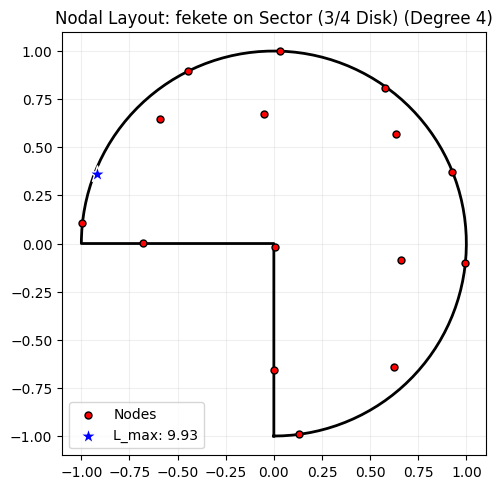

✅ Experiment Successful: Square | Method: leja | Nodes N=21 | L_max=6.33


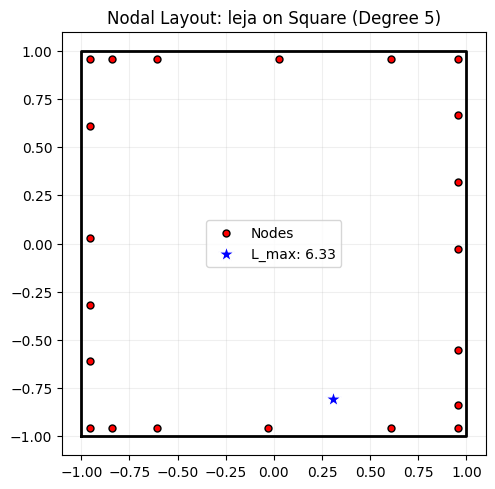


--- Step 3: Generating High-Resolution Academic Graphs ---


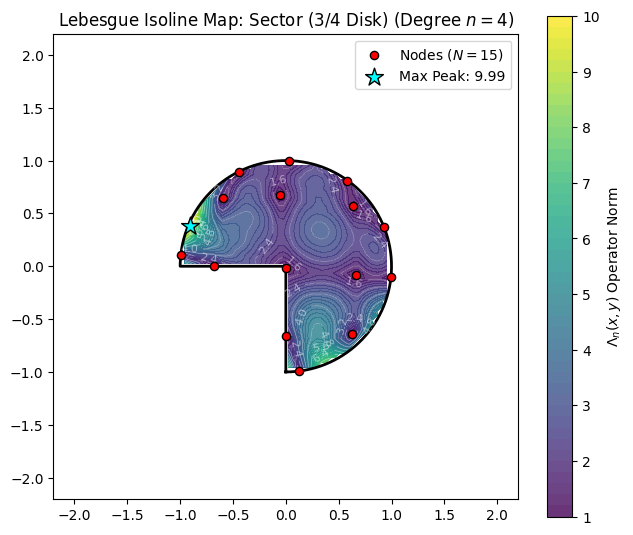

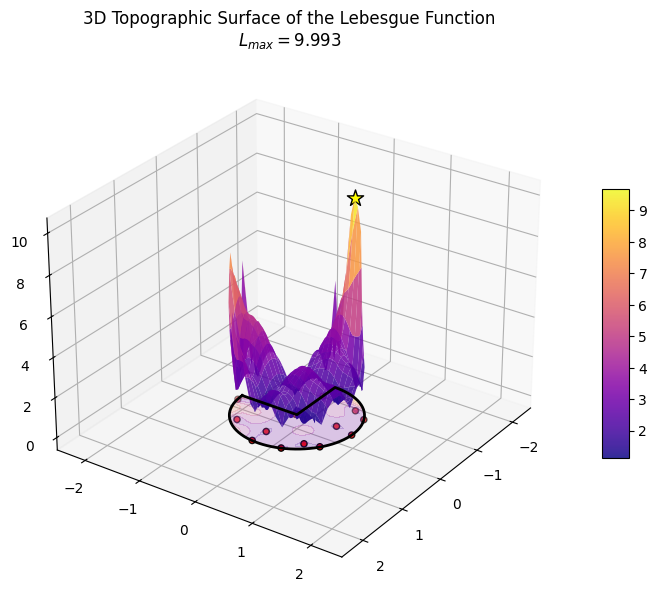


--- Step 4: Activating Interactive Laboratory Module ---



--- Step 5: Testing Volumetric 3D Manifold Partitioning ---



--- Step 6: Automating LaTeX Data Export for the Thesis Document ---

📋 SUMMARY EXPERIMENT LOG EXPORTED FOR LATEX:
\begin{table}[h!]\centering
\begin{tabular}{|l|l|c|r|}\hline
Geometric Topology Domain & Mathematical Solver Method & Node Count ($N$) & $L_{max}$ Stability \\ \hline
Sector (3/4 Disk) & fekete & 15 & 9.933 \\ \hline
Square & leja & 21 & 6.328 \\ \hline
\end{tabular}\caption{Comparative Stability Analysis of Numerical Lebesgue Constants}\end{table}


In [23]:
# =====================================================================
# 7. EXECUTION SANDBOX: RUNNING EXPERIMENTS FOR THE THESIS
# =====================================================================

# Clear previously recorded logs just in case
stats_journal.clear()

print("--- Step 1: Initializing Geometric Domains ---")
square_domain = Square()
sector_disk = Sector()
torus_3d = Torus3D()

print("\n--- Step 2: Running Standard 2D Numerical Experiments ---")
# Experiment A: Approximate Fekete Points on a complex non-convex 3/4 Sector Disk
# Generates nodes, calculates Lebesgue constant, and logs data
nodes_fekete = run_experiment(sector_disk, method="fekete", degree=4, res=80)

# Experiment B: Multidimensional Leja Sequences on a standard Square domain
nodes_leja = run_experiment(square_domain, method="leja", degree=5, res=80)


print("\n--- Step 3: Generating High-Resolution Academic Graphs ---")
if nodes_fekete is not None:
    # Render the gorgeous 2D Isoline Contour Heatmap
    plot_lebesgue_analysis_2d(nodes_fekete, sector_disk, degree=4, res=100)

    # Render the monumental 3D Lebesgue Topographic Surface Relief
    plot_lebesgue_surface_3d(nodes_fekete, sector_disk, degree=4, res=100)


print("\n--- Step 4: Activating Interactive Laboratory Module ---")
# This opens the GUI with arrow buttons where you can manipulate node coordinates manually
final_interactive_lab(square_domain, method="fekete", degree=3)


print("\n--- Step 5: Testing Volumetric 3D Manifold Partitioning ---")
# Generates 3D points inside a Solid Torus and runs the dynamic Z-slice tool
nodes_torus = get_nodes("leja", torus_3d, degree=4)
if nodes_torus is not None:
    interactive_3d_slice(nodes_torus, "leja", torus_3d)


print("\n--- Step 6: Automating LaTeX Data Export for the Thesis Document ---")
# Prints out a fully compiled LaTeX tabular block based on today's logged data
export_journal_to_latex()